In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import dataclass
from py_files.capinc import CapIncModel

import py_files.simulation_fig as simulation_fig
import py_files.var_groups as var_groups
import py_files.dk_emp_tax as dk_emp_tax  
import numpy as np
import matplotlib.pyplot as plt
import importlib
import math
import py_files.fig_setup as fs
import matplotlib.ticker as mticker

importlib.reload(fs)     
fs.set_aej()    

# `Solving`the dynamic problem

**Intention:** I build a class, that performs the necessary steps to replicate `Figure 5`in the paper. 

**Outcome:** Get a better grasp on the model dynamics and replicate their results - then only DK-calibration/extention is left.

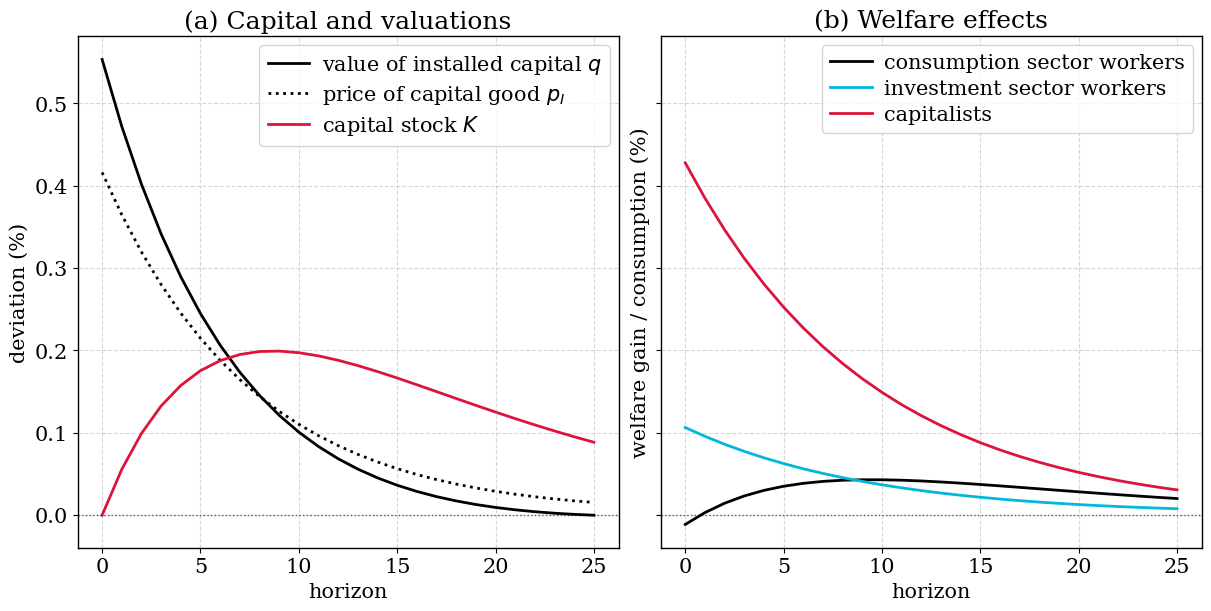

In [2]:
# run
m = CapIncModel()
fig, axes, ss, sim = simulation_fig.plot_figure5(m, T=25, tau_ss=0.0, size=0.01, decay=0.10)
plt.show()

> Do comparatison between their and my calibration for paper.

*Labour shares*

In [3]:
gamma = 0.4

m = CapIncModel()
ss = m.solve_steady_state()
net_t1, tau_t1, dlog_net1 = m.net_tax_path(T=25, tau_ss=0.0, size=0.01, decay=0.10)

sim1 = m.solve_transition(tau_path=tau_t1)
ls1  = simulation_fig.labour_share(m, sim, gamma=gamma)

net_t2, tau_t2, dlog_net2 = m.net_tax_path(T=25, tau_ss=0.0, size=0.0, decay=0.0)
sim2 = m.solve_transition(tau_path=tau_t2)
ls2  = simulation_fig.labour_share(m, sim2, gamma=gamma)

h = np.arange(len(ls1["LS"]))

c:\Users\LinusLindquist\anaconda3\Lib\site-packages\scipy\optimize\_nonlin.py:374: RuntimeWarning: invalid value encountered in scalar divide
  and dx_norm/self.x_rtol <= x_norm))


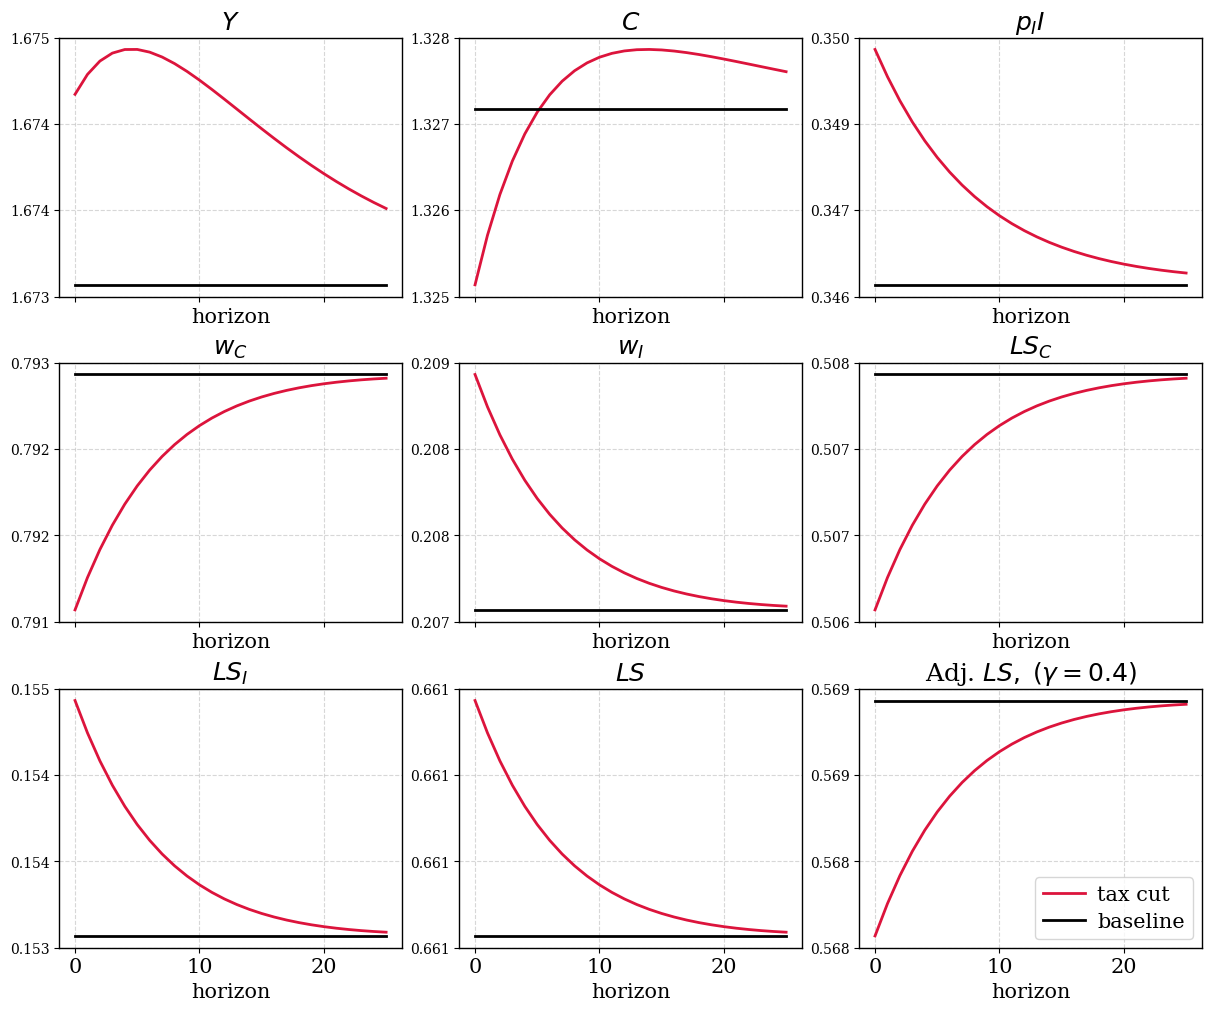

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, constrained_layout=True)
axes = axes.ravel()

# plot the 7 used panels
for i, (k, ttl) in enumerate(var_groups.panels(gamma)):
    ax = axes[i]
    l1, = ax.plot(h, ls1[k], lw=2, color="crimson", label="tax cut")
    l2, = ax.plot(h, ls2[k], lw=2, color="k",       label="baseline")
    ax.set_title(ttl)
    ax.set_xlabel("horizon")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="y", labelsize=10)

plt.legend()
plt.show()

> Could an argument be make for $LS_C$ being the main labour share and then (at least some of) $LS_I$ not counting a labour? 
>
> Then simulating a falling path of the tax rate (base on the real empirical fall) could suggest a mechanism putting downward pressure on the labour income share. This is essentially:
>$$
>    LS' = LS_C + \gamma LS_I, \quad \gamma\in[0,1]
>$$
> where an empirical argument could be made for $\gamma$.
>
>*“how much of what the model calls labour income in the investment/intangible sector should be counted as labour in the empirical labour share series I’m targeting?”*

*All key variable dynamics*

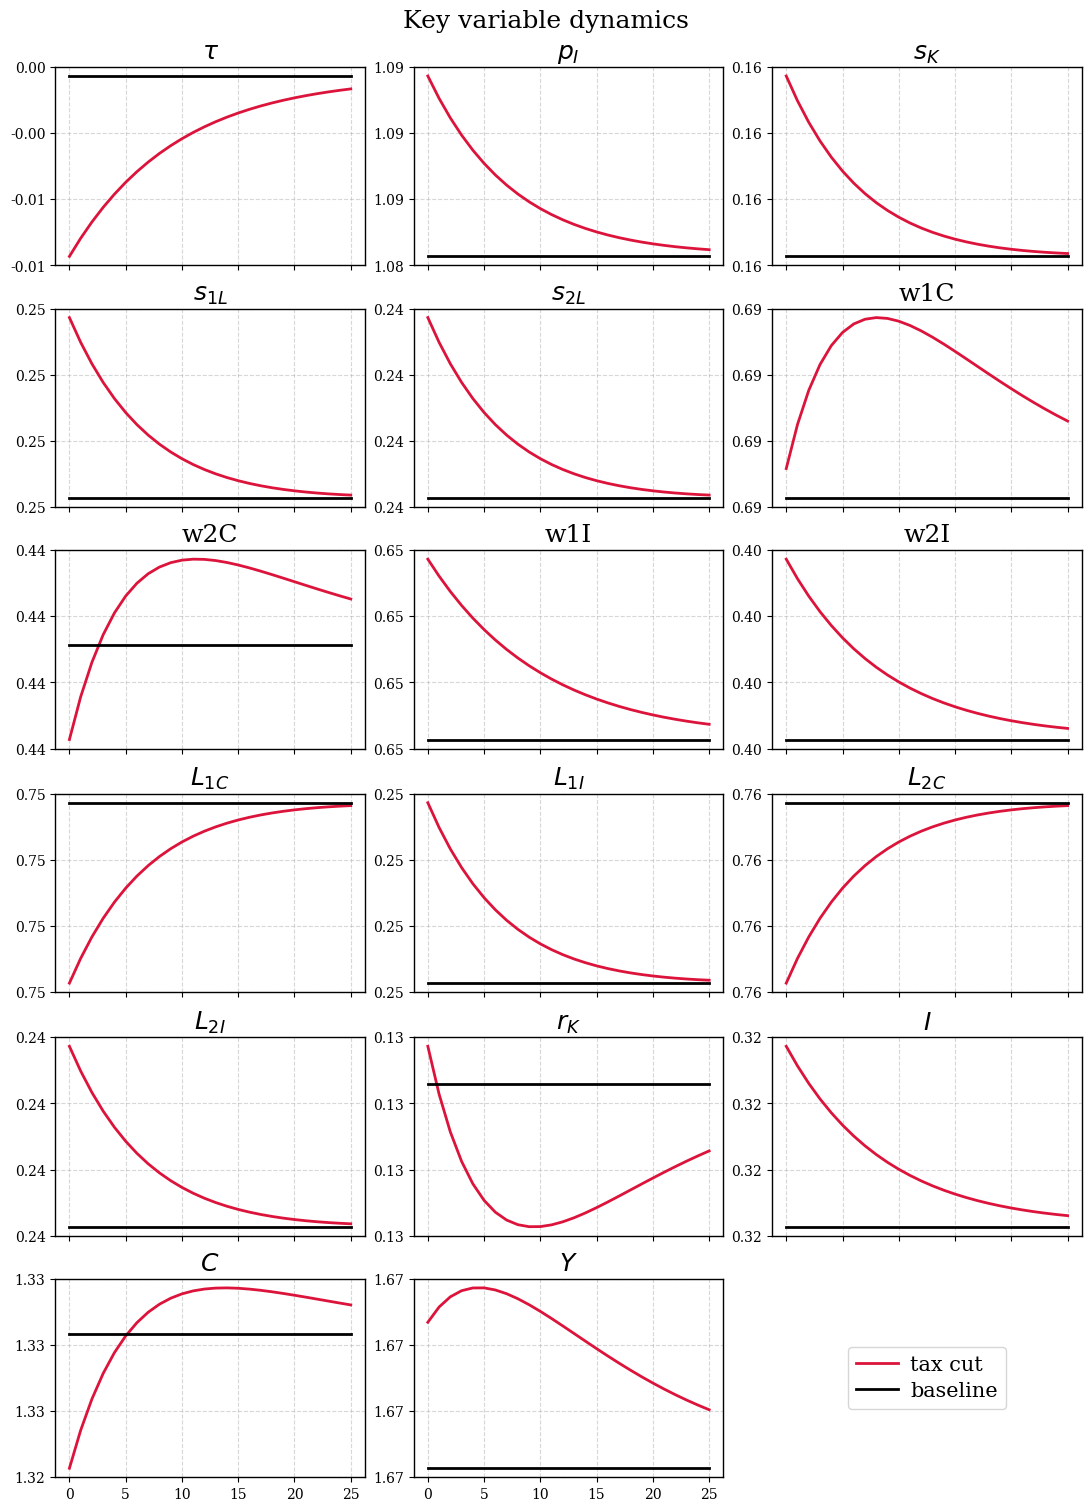

In [5]:
# pack everything
S1 = {**sim1, **ls1}
S2 = {**sim2, **ls2}

# choose/order keys (edit freely)
keys = [
    "tau",'pI',
    "sK","s1","s2",
    "w1C","w2C","w1I","w2I",
    "L1C","L1I","L2C","L2I",
    "rC_gross","I","C","Y"
]

T = min(len(S1[keys[0]]), len(S2[keys[0]]))
h = np.arange(T)

ncols = 3
nrows = math.ceil(len(keys) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.6*ncols, 2.5*nrows),
    sharex=True,
    constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()
fig.suptitle('Key variable dynamics')

for i, k in enumerate(keys):
    ax = axes[i]
    ax.plot(h, np.asarray(S1[k])[:T], lw=2, color="crimson")
    ax.plot(h, np.asarray(S2[k])[:T], lw=2, color="k")
    ax.set_title(var_groups.model_var.get(k, k))
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

for ax in axes:
    ax.yaxis.set_major_locator(mticker.LinearLocator(4))
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)
    
    
# hide any unused panels
for j in range(len(keys), len(axes)):
    axes[j].set_axis_off()

# one legend for the whole figure
axes[0].plot([], [], lw=2, color="crimson", label="tax cut")
axes[0].plot([], [], lw=2, color="k",  label="baseline")

first_empty = len(keys)

# 2) turn all unused axes off
for j in range(first_empty, len(axes)):
    axes[j].set_axis_off()

# 3) use the first empty one to host the legend
if first_empty < len(axes):
    ax_leg = axes[first_empty]
    ax_leg.set_axis_off()

    # proxy handles (clean + independent of what's plotted)
    h1 = plt.Line2D([0], [0], color="crimson", lw=2)
    h2 = plt.Line2D([0], [0], color="k",  lw=2)

    ax_leg.legend([h1, h2], ["tax cut", "baseline"], loc="center", frameon=True)

plt.show()

> Interesting heterogeneity in the wage and labour force allocation between type 1 and 2, could be included in argument for who moves and it's effects.
>
> NTS: need to understand that heterogeneity better.